# 02 · Clasificador de referencia

**Taller B5-T1 · Generación de datos financieros sinteticos**

Antes de generar un solo dato sintetico es necesario fijar dos cosas: la
arquitectura que resolvera el problema y el nivel de rendimiento que alcanza
utilizando exclusivamente datos reales. Sin esa referencia, cualquier resultado
posterior careceria de punto de comparación.

Este notebook establece además el **presupuesto de datos reales** con el que
trabajaran todos los generadores, y examina como responde el clasificador a la
cantidad de datos disponible. Ese examen resulta determinante para entender que
puede y que no puede aportar un modelo generativo en este problema.

**Salida:** `results/tablas/resultados_baseline.csv`

## Preparación del entorno

Se fija el backend de cómputo, se añade el código común del proyecto a la ruta
de importación y se aplica el estilo gráfico compartido. El bloque funciona sin
cambios tanto en una instalación local como en Colab.

In [1]:
import os
import sys

# Keras 3 se ejecuta sobre PyTorch: la versión de Python empleada no dispone de
# TensorFlow y la API de capas y modelos es idéntica en ambos backends.
os.environ["KERAS_BACKEND"] = "torch"

EN_COLAB = "google.colab" in sys.modules

if EN_COLAB:
    !pip install -q yfinance keras torch
    # En Colab se asume que el repositorio está clonado en el directorio actual.
    RAIZ = "/content/B5-T1"
else:
    RAIZ = os.path.dirname(os.getcwd())

if os.path.join(RAIZ, "src") not in sys.path:
    sys.path.insert(0, os.path.join(RAIZ, "src"))

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from miax_b5t1 import config, datos, experimento, graficos, modelo

graficos.aplicar_estilo()
config.asegurar_directorios()

print(f"Keras {keras.__version__} sobre backend {keras.backend.backend()}")
print(f"Raíz del proyecto: {RAIZ}")

Keras 3.15.1 sobre backend torch
Raíz del proyecto: C:\Users\raulr\Documents\MIAX\Practicas\B5-T1


## 1. Carga del conjunto

Se recupera el dataset preparado en el notebook 00. Las particiones llegan ya
escaladas y no se vuelve a tocar ninguna decisión de preprocesado.

In [2]:
d = datos.cargar_dataset()

X_train_total, y_train_total = d["X_train"], d["y_train"]
X_val, y_val = d["X_val"], d["y_val"]
X_test, y_test = d["X_test"], d["y_test"]

print(f"Entrenamiento disponible: {X_train_total.shape}, "
      f"{y_train_total.mean():.1%} positivas")
print(f"Validación:               {X_val.shape}, {y_val.mean():.1%} positivas")
print(f"Test:                     {X_test.shape}, {y_test.mean():.1%} positivas")

Entrenamiento disponible: (11326, 60, 23), 10.0% positivas
Validación:               (2337, 60, 23), 12.8% positivas
Test:                     (2337, 60, 23), 10.4% positivas


## 2. Criterio de evaluación

Con una clase positiva que ronda el diez por ciento, la tasa de acierto global
no sirve como criterio: un modelo que responda siempre "no habra caída" acierta
nueve de cada diez veces sin haber aprendido nada. La evaluación se apoya por
tanto en el **area bajo la curva de precisión y exhaustividad**, cuyo valor de
referencia para un clasificador sin información coincide con la proporción de
positivos del conjunto.

Se reportan también F1, precisión y exhaustividad. El punto de corte no se fija
en 0.5 sino que se ajusta en validación maximizando F1, y despues se aplica al
test sin revisarlo.

Como referencia adicional se entrena una regresión logistica sobre descriptores
agregados de la ventana. Sirve para comprobar si la red convolucional aporta algo
por encima de un resumen estadístico sencillo.

In [3]:
tasa_base = float(y_test.mean())
print(f"PR-AUC de un clasificador sin información: {tasa_base:.4f}")

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import StandardScaler

def descriptores(X):
    ret_cartera = X.mean(axis=2)
    trayectoria = np.cumsum(ret_cartera, axis=1)
    maximo_movil = np.maximum.accumulate(trayectoria, axis=1)
    return np.column_stack([
        ret_cartera.std(axis=1),
        ret_cartera.sum(axis=1),
        (trayectoria - maximo_movil).min(axis=1),
        ret_cartera.min(axis=1),
        X.std(axis=2).mean(axis=1),
        np.abs(ret_cartera).mean(axis=1),
    ])

escalador_lineal = StandardScaler().fit(descriptores(X_train_total))
modelo_lineal = LogisticRegression(max_iter=2000, class_weight="balanced").fit(
    escalador_lineal.transform(descriptores(X_train_total)), y_train_total)

pr_lineal = average_precision_score(
    y_test,
    modelo_lineal.predict_proba(escalador_lineal.transform(descriptores(X_test)))[:, 1])
print(f"PR-AUC de una regresión logistica sobre descriptores: {pr_lineal:.4f}")

PR-AUC de un clasificador sin información: 0.1040


PR-AUC de una regresión logistica sobre descriptores: 0.3498


## 3. Arquitectura

La red reproduce el esquema convolucional unidimensional empleado en el taller:
tres bloques de convolución y submuestreo que recorren la dimensión temporal de
la ventana tratando los veintitres activos como canales, seguidos de una capa
densa. La convolución resulta apropiada aquí porque los patrones que interesan,
como una racha de sesiones volatiles, son locales y pueden aparecer en cualquier
posición de la ventana.

Las dos adaptaciones respecto al original son la salida, que pasa a ser una
unidad con activación sigmoide propia de un problema binario, y la incorporación
de una capa de abandono antes de la salida para contener el sobreajuste, que con
pocos ejemplos positivos aparece muy pronto.

La arquitectura queda fijada aquí y **no se modifica en ninguna configuración
posterior**. Es la condición que exige el enunciado para que las diferencias
observadas sean atribuibles a los datos y no al modelo.

In [4]:
clasificador = modelo.construir_clasificador(
    X_train_total.shape[1], X_train_total.shape[2], semilla=config.SEMILLA)
clasificador.summary()

print(f"\nParametros entrenables: {clasificador.count_params():,}")

Model: "clasificador_drawdown"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 58, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 27, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 13, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 11, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        64,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,665 (557.29 KB)

 Trainable params: 142,665 (557.29 KB)

 Non-trainable params: 0 (0.00 B)


Parametros entrenables: 142,665


El desequilibrio entre clases se compensa ponderando la entropia cruzada de
forma inversamente proporcional a la frecuencia de cada clase. La ponderación se
aplica de manera identica en todas las configuraciones del estudio, de modo que
no favorece a ninguna en la comparativa.

In [5]:
pesos = modelo.pesos_de_clase(y_train_total)
print("Ponderación aplicada a la función de pérdida:")
for clase, peso in pesos.items():
    print(f"  clase {int(clase)}: {peso:.3f}")

Ponderación aplicada a la función de pérdida:
  clase 0: 0.556
  clase 1: 4.981


## 4. Rendimiento con la totalidad de los datos reales

Se entrena en primer lugar con el conjunto de entrenamiento completo, que
constituye el máximo de información histórica disponible.

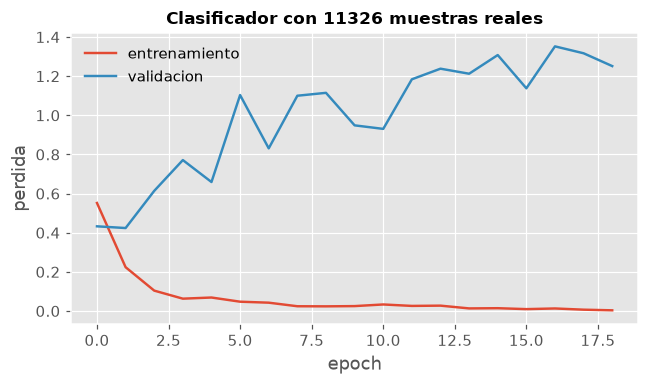

Epochs efectivos: 19


,valor
pr_auc,0.175437
roc_auc,0.521345
f1,0.163333
precision,0.137255
recall,0.201646
umbral,0.060000
vn,1786.000000
fp,308.000000
fn,194.000000
vp,49.000000


In [6]:
clasificador_total, historia_total = modelo.entrenar_clasificador(
    X_train_total, y_train_total, X_val, y_val, semilla=config.SEMILLA, verbose=0)

umbral_total = modelo.umbral_optimo(clasificador_total, X_val, y_val)
metricas_total = modelo.evaluar(clasificador_total, X_test, y_test, umbral=umbral_total)

graficos.curva_perdida(
    historia_total.history,
    f"Clasificador con {len(X_train_total)} muestras reales",
    "02_perdida_train_completo")
plt.show()

print(f"Epochs efectivos: {len(historia_total.history['loss'])}")
display(pd.Series(metricas_total).to_frame("valor"))

## 5. Curva de aprendizaje

Se repite el entrenamiento variando el número de muestras reales disponibles. El
muestreo es estratificado, de modo que la proporción de positivos se mantiene
constante y la única variable es el volumen. Cada tamaño se evalua con varias
semillas para separar el efecto real de la variabilidad del ajuste.

La curva se mide simultáneamente sobre validación y sobre test. La comparación
entre ambas permite distinguir dos fenomenos que de otro modo se confundirian: la
capacidad del modelo de aprovechar más datos y la estabilidad del problema a lo
largo del tiempo.

In [7]:
tamaños = [500, 1000, 2000, 3000, 5000, 8000, len(X_train_total)]
filas_curva = []

for n in tamaños:
    for k in range(config.N_SEMILLAS):
        semilla = config.SEMILLA + k
        X_sub, y_sub = datos.submuestra_real(X_train_total, y_train_total, n, semilla)
        m, h = modelo.entrenar_clasificador(X_sub, y_sub, X_val, y_val, semilla=semilla)
        u = modelo.umbral_optimo(m, X_val, y_val)
        met = modelo.evaluar(m, X_test, y_test, umbral=u)
        met["pr_auc_val"] = modelo.evaluar(m, X_val, y_val, umbral=u)["pr_auc"]
        met.update({"n_reales": len(X_sub), "semilla": semilla,
                    "epochs": len(h.history["loss"])})
        filas_curva.append(met)
    últimas = filas_curva[-config.N_SEMILLAS:]
    print(f"n = {n:>6d}  PR-AUC test = {np.mean([f['pr_auc'] for f in últimas]):.4f}   "
          f"PR-AUC validación = {np.mean([f['pr_auc_val'] for f in últimas]):.4f}")

curva = pd.DataFrame(filas_curva)
resumen_curva = curva.groupby("n_reales").agg(
    pr_auc_media=("pr_auc", "mean"), pr_auc_std=("pr_auc", "std"),
    pr_auc_val_media=("pr_auc_val", "mean"), pr_auc_val_std=("pr_auc_val", "std"),
    f1_media=("f1", "mean"), recall_media=("recall", "mean"),
    epochs_medios=("epochs", "mean")).reset_index()
display(resumen_curva.round(4))

n =    500  PR-AUC test = 0.3041   PR-AUC validación = 0.3334


n =   1000  PR-AUC test = 0.2755   PR-AUC validación = 0.2967


n =   2000  PR-AUC test = 0.2579   PR-AUC validación = 0.3321


n =   3000  PR-AUC test = 0.2734   PR-AUC validación = 0.3275


n =   5000  PR-AUC test = 0.2215   PR-AUC validación = 0.3051


n =   8000  PR-AUC test = 0.2256   PR-AUC validación = 0.3058


n =  11326  PR-AUC test = 0.1911   PR-AUC validación = 0.3238


,n_reales,pr_auc_media,pr_auc_std,pr_auc_val_media,pr_auc_val_std,f1_media,recall_media,epochs_medios
0,500,0.3041,0.0253,0.3334,0.0139,0.2671,0.2189,13.4
1,1000,0.2755,0.0387,0.2967,0.0372,0.2653,0.3193,15.8
2,2000,0.2579,0.0308,0.3321,0.0201,0.2373,0.3654,21.6
3,3000,0.2734,0.0530,0.3275,0.0277,0.2510,0.3852,17.2
4,5000,0.2215,0.0424,0.3051,0.0210,0.2199,0.3877,18.0
5,8000,0.2256,0.0431,0.3058,0.0250,0.2052,0.3416,15.8
6,11326,0.1911,0.0607,0.3238,0.0594,0.1703,0.2798,21.4


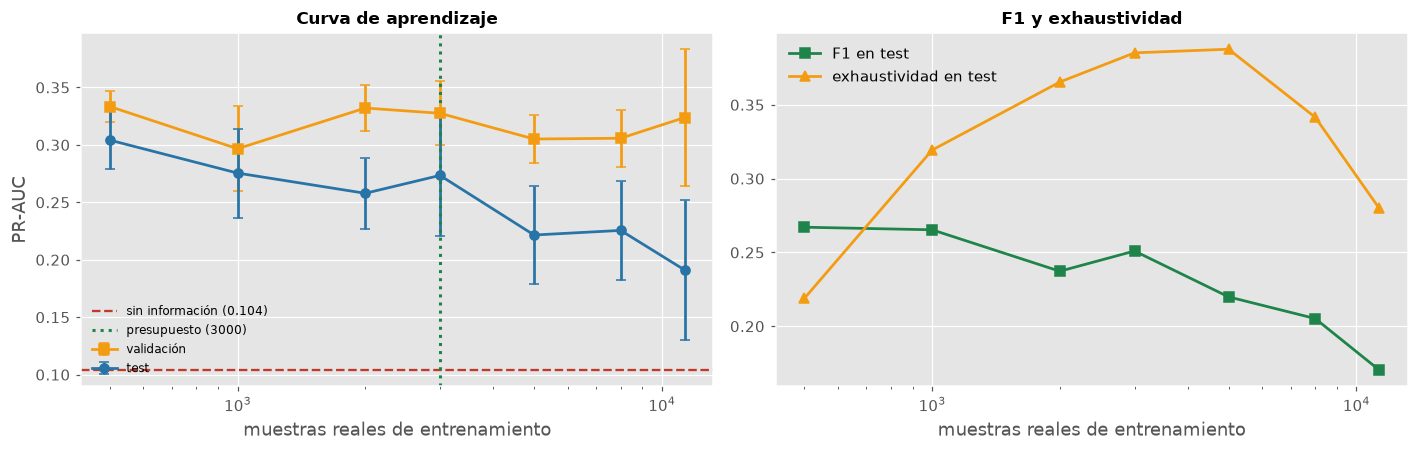

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].errorbar(resumen_curva["n_reales"], resumen_curva["pr_auc_val_media"],
                 yerr=resumen_curva["pr_auc_val_std"], marker="s", capsize=3,
                 color="#f39c12", linewidth=1.8, label="validación")
axes[0].errorbar(resumen_curva["n_reales"], resumen_curva["pr_auc_media"],
                 yerr=resumen_curva["pr_auc_std"], marker="o", capsize=3,
                 color="#2874a6", linewidth=1.8, label="test")
axes[0].axhline(tasa_base, color="#c0392b", linestyle="--",
                label=f"sin información ({tasa_base:.3f})")
axes[0].axvline(config.N_REALES, color="#1e8449", linestyle=":", linewidth=2,
                label=f"presupuesto ({config.N_REALES})")
axes[0].set_xscale("log")
axes[0].set_xlabel("muestras reales de entrenamiento")
axes[0].set_ylabel("PR-AUC")
axes[0].set_title("Curva de aprendizaje")
axes[0].legend(fontsize=8)

axes[1].plot(resumen_curva["n_reales"], resumen_curva["f1_media"],
             marker="s", color="#1e8449", linewidth=1.8, label="F1 en test")
axes[1].plot(resumen_curva["n_reales"], resumen_curva["recall_media"],
             marker="^", color="#f39c12", linewidth=1.8, label="exhaustividad en test")
axes[1].set_xscale("log")
axes[1].set_xlabel("muestras reales de entrenamiento")
axes[1].set_title("F1 y exhaustividad")
axes[1].legend()

fig.tight_layout()
graficos.guardar(fig, "02_curva_aprendizaje")
plt.show()

La lectura conjunta de ambas curvas resulta más informativa de lo previsto.

En **validación** el rendimiento es prácticamente plano: pasar de quinientas a
once mil muestras reales no lo mejora de forma apreciable. El clasificador extrae
casi toda la señal disponible con una fracción mínima de los datos, y el resto
son en su mayor parte repeticiones de configuraciones ya vistas, consecuencia
directa del solapamiento entre ventanas documentado en el análisis exploratorio.

En **test** la curva llega incluso a descender. La explicación no es un fallo de
ajuste sino un cambio en el propio problema: entrenar con más historia significa
entrenar con más decadas antiguas, y el periodo de test corresponde a un régimen
de mercado distinto del que domina el conjunto de entrenamiento. El modelo se
especializa en configuraciones que han dejado de ser representativas.

La conclusión metodologica conviene enunciarla sin rodeos: **este problema no
esta limitado por el volumen de datos**. Añadir historia no mejora el resultado.
Lo que escasea es la variedad de episodios de estrés, no el número de
observaciones, y son dos carencias distintas.

### 5.1 La escasez, vista de cerca

Una comprobación adicional ilustra el punto. Si en lugar de muestrear al azar
sobre toda la historia se toman las últimas sesiones del bloque de entrenamiento,
que es la situación de quien dispone únicamente de datos recientes, el resultado
es revelador.

In [9]:
for n in [500, 1000, 2000, 3000]:
    y_reciente = y_train_total[-n:]
    print(f"últimas {n:>5d} ventanas de entrenamiento -> "
          f"{int(y_reciente.sum()):>4d} positivas ({y_reciente.mean():.1%})")

últimas   500 ventanas de entrenamiento ->    0 positivas (0.0%)
últimas  1000 ventanas de entrenamiento ->    0 positivas (0.0%)
últimas  2000 ventanas de entrenamiento ->  257 positivas (12.8%)
últimas  3000 ventanas de entrenamiento ->  337 positivas (11.2%)


Los tramos recientes más cortos no contienen **ningún** episodio de caída severa.
Un clasificador entrenado sobre ellos no puede aprender nada, y no porque le
falten observaciones sino porque le falta el fenomeno entero.

Esto delimita con precisión lo que cabe esperar de un modelo generativo aquí. Su
utilidad no consiste en fabricar más observaciones, que sobran, sino en producir
configuraciones de estrés plausibles y distintas entre si a partir de las pocas
disponibles. Si un generador lo consigue, debería notarse; si se limita a
reproducir lo que ya hay, no cambiara nada.

## 6. Elección del presupuesto de datos reales

El presupuesto queda fijado en el valor de `config.N_REALES`. Se sitúa en la
región donde el clasificador ya extrae señal de forma estable pero dispone aún de
un número reducido de episodios de estrés, y donde la varianza entre semillas se
mantiene manejable. Un presupuesto mucho menor dejaria a los generadores sin
material suficiente con el que aprender la distribución; uno mucho mayor no
cambiaria el resultado, como acaba de mostrar la curva de aprendizaje.

Conviene subrayar un punto metodologico: **los generadores se entrenan
exclusivamente con este mismo subconjunto**, nunca con la totalidad del
histórico. De lo contrario dispondrian de información vedada al clasificador y la
comparación perderia todo sentido.

In [10]:
X_real, y_real = datos.submuestra_real(
    X_train_total, y_train_total, config.N_REALES, config.SEMILLA)

print(f"Presupuesto de datos reales: {len(X_real)} ventanas")
print(f"Positivas: {int(y_real.sum())} ({y_real.mean():.1%})")

fila_presupuesto = resumen_curva.loc[
    resumen_curva["n_reales"] == config.N_REALES].iloc[0]
fila_completo = resumen_curva.loc[
    resumen_curva["n_reales"] == len(X_train_total)].iloc[0]

print(f"\nCon el presupuesto ({config.N_REALES} muestras):")
print(f"  PR-AUC en test:       {fila_presupuesto['pr_auc_media']:.4f} "
      f"+- {fila_presupuesto['pr_auc_std']:.4f}")
print(f"  PR-AUC en validación: {fila_presupuesto['pr_auc_val_media']:.4f}")
print(f"\nCon el histórico completo ({len(X_train_total)} muestras):")
print(f"  PR-AUC en test:       {fila_completo['pr_auc_media']:.4f} "
      f"+- {fila_completo['pr_auc_std']:.4f}")
print(f"  PR-AUC en validación: {fila_completo['pr_auc_val_media']:.4f}")

Presupuesto de datos reales: 3000 ventanas
Positivas: 301 (10.0%)

Con el presupuesto (3000 muestras):
  PR-AUC en test:       0.2734 +- 0.0530
  PR-AUC en validación: 0.3275

Con el histórico completo (11326 muestras):
  PR-AUC en test:       0.1911 +- 0.0607
  PR-AUC en validación: 0.3238


## 7. Referencia definitiva

Se ejecuta por último el protocolo de evaluación común con el presupuesto fijado
y sin ningún dato sintetico. El resultado es la fila de referencia frente a la
que se compararan todos los generadores, y se genera con exactamente el mismo
código que ellos utilizaran, de modo que ninguna diferencia pueda atribuirse al
procedimiento de medida.

In [11]:
resultados_baseline, historias_baseline = experimento.barrido_ratios(
    "baseline", X_real, y_real, None, None,
    X_val, y_val, X_test, y_test, ratios=[0.0])

ruta = experimento.guardar_resultados(resultados_baseline, "baseline")
print(f"\nGuardado en {ruta}")
display(experimento.resumir(resultados_baseline).round(4))

  baseline   ratio=0.00  semilla=42 PR-AUC(test)=0.3372 PR-AUC(val)=0.3276 F1=0.2755


  baseline   ratio=0.00  semilla=43 PR-AUC(test)=0.2906 PR-AUC(val)=0.3649 F1=0.2970


  baseline   ratio=0.00  semilla=44 PR-AUC(test)=0.1680 PR-AUC(val)=0.3235 F1=0.1887


  baseline   ratio=0.00  semilla=45 PR-AUC(test)=0.1158 PR-AUC(val)=0.3074 F1=0.1732


  baseline   ratio=0.00  semilla=46 PR-AUC(test)=0.3101 PR-AUC(val)=0.3281 F1=0.2566

Guardado en C:\Users\raulr\Documents\MIAX\Practicas\B5-T1\results\tablas\resultados_baseline.csv


,modelo,ratio,pr_auc_media,pr_auc_std,pr_auc_val_media,pr_auc_val_std,f1_media,f1_std,recall_media,precision_media,n_sinteticos
0,baseline,0.0,0.2443,0.0967,0.3303,0.0211,0.2382,0.0544,0.279,0.2701,0


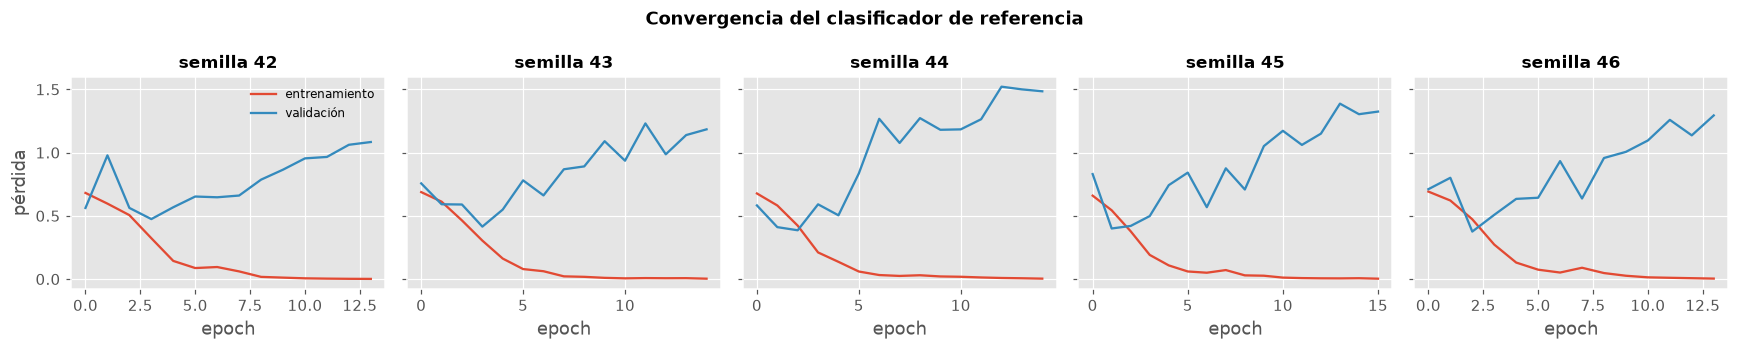

In [12]:
n_paneles = min(config.N_SEMILLAS, len(historias_baseline))
fig, axes = plt.subplots(1, n_paneles, figsize=(3.2 * n_paneles, 3.2), sharey=True)
axes = np.atleast_1d(axes)

for ax, ((ratio, semilla), historia) in zip(axes, sorted(historias_baseline.items())):
    ax.plot(historia["loss"], label="entrenamiento", linewidth=1.5)
    ax.plot(historia["val_loss"], label="validación", linewidth=1.5)
    ax.set_title(f"semilla {semilla}")
    ax.set_xlabel("epoch")

axes[0].set_ylabel("pérdida")
axes[0].legend(fontsize=8)
fig.suptitle("Convergencia del clasificador de referencia", fontweight="bold")
fig.tight_layout()
graficos.guardar(fig, "02_perdida_baseline")
plt.show()

## Conclusiones del notebook

1. **La arquitectura extrae señal real.** El PR-AUC supera con holgura la tasa
   base de un clasificador sin información, lo que confirma que la ventana de
   rentabilidades contiene información sobre el riesgo de caída a treinta días.
2. **En terminos absolutos el rendimiento es modesto.** Era lo esperable a la
   vista del solapamiento entre clases documentado en el análisis exploratorio.
   Anticipar caídas de mercado es un problema difícil, y unas metricas
   espectaculares habrian sido más motivo de sospecha que de satisfacción.
3. **El problema no esta limitado por el volumen de datos.** La curva de
   aprendizaje es plana en validación y descendente en test. Multiplicar por
   veinte el número de observaciones no mejora el resultado, porque las ventanas
   se solapan y aportan poca información nueva, y porque la historia más antigua
   corresponde a un régimen distinto del que se evalua.
4. **Lo que escasea es la variedad de episodios de estrés.** Los tramos recientes
   del entrenamiento llegan a no contener ninguno. Esta es la carencia concreta
   que un modelo generativo podría compensar, y la que se pone a prueba en los
   notebooks siguientes.
5. **La comparación se apoyara en validación y test a la vez.** Dado que el test
   cubre un único régimen de mercado y sus metricas son ruidosas, atender a una
   sola de las particiones daría lugar a conclusiones fragiles.
6. **Queda establecida la referencia** frente a la que se mediran los cuatro
   generadores, obtenida con el mismo protocolo que se aplicara a todos ellos.